In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("../"))
import photospline

from icecube import dataio, icetray, dataclasses, simclasses, gulliver
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from scripts.python.SplineEval import evalLogPdf, evalPdf
from matplotlib.colors import LogNorm

import pandas as pd
pd.set_option('display.max_rows', 20)

In [46]:
cdfs = np.load('/mnt/home/dillonb5/cascades/bad_params_truth4_7-21.npy')
hist, edges = np.histogram(cdfs[:,0], bins=100)
idx = 0
maxval = 0
# for i in range(len(hist)):
#     if hist[i] > maxval:
#         maxval = hist[i]
#         idx = i

# print(idx, hist[idx])
# print(edges[idx], edges[idx+1])

for i in range(len(hist)):
    print(edges[i], edges[i+1], hist[i])
cdf = []
dist = []
phiE = []
tres = []
for ary in cdfs:
    if (ary[0] > edges[idx]) & (ary[0] < edges[idx+1]):
        cdf.append(ary[0])
        dist.append(ary[1])
        phiE.append(ary[2])
        tres.append(ary[3])
print(len(cdf))


9.271211891162334e-07 0.010000884548866006 6485
0.010000884548866006 0.020000841976542897 7847
0.020000841976542897 0.030000799404219788 10210
0.030000799404219788 0.04000075683189668 3530
0.04000075683189668 0.05000071425957357 2461
0.05000071425957357 0.06000067168725046 17668
0.06000067168725046 0.07000062911492734 2592
0.07000062911492734 0.08000058654260424 3367
0.08000058654260424 0.09000054397028114 3074
0.09000054397028114 0.10000050139795802 2547
0.10000050139795802 0.1100004588256349 24240
0.1100004588256349 0.1200004162533118 2269
0.1200004162533118 0.1300003736809887 3057
0.1300003736809887 0.14000033110866558 2764
0.14000033110866558 0.15000028853634248 3685
0.15000028853634248 0.16000024596401938 1473
0.16000024596401938 0.17000020339169628 3201
0.17000020339169628 0.18000016081937317 28496
0.18000016081937317 0.19000011824705004 3541
0.19000011824705004 0.20000007567472694 2639
0.20000007567472694 0.21000003310240384 1927
0.21000003310240384 0.2199999905300807 1877
0.219

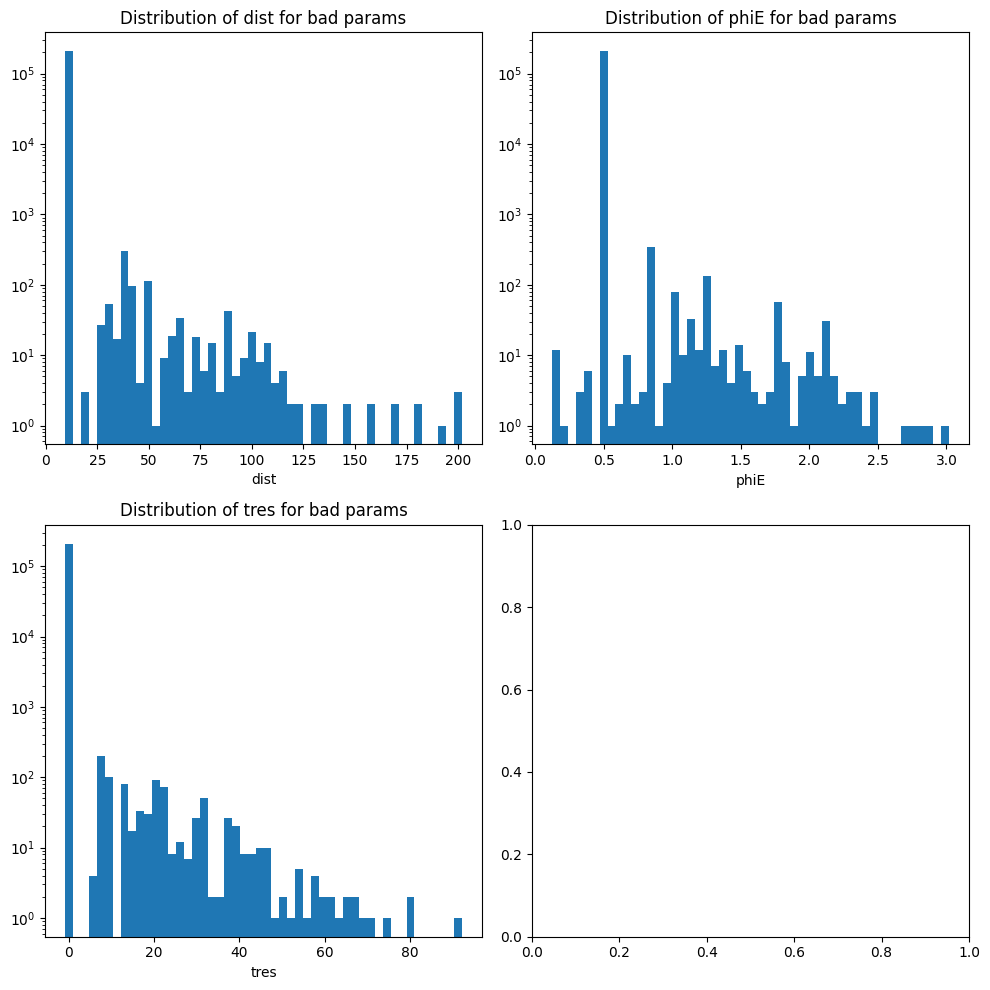

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 0].hist(dist, bins=50)
axs[0, 0].set_title('Distribution of dist for bad params')
axs[0, 0].set_xlabel('dist')
axs[0,0].set_yscale('log')

axs[0, 1].hist(phiE, bins=50)
axs[0, 1].set_title('Distribution of phiE for bad params')
axs[0, 1].set_xlabel('phiE')
axs[0,1].set_yscale('log')

axs[1, 0].hist(tres, bins=50)
axs[1, 0].set_title('Distribution of tres for bad params')
axs[1, 0].set_xlabel('tres')
axs[1,0].set_yscale('log')

fig.tight_layout()

plt.show()

In [9]:
sorted_cdfs = np.sort(cdfs, axis=0)

In [26]:
len(sorted_cdfs)

251411

In [19]:
splinefit_3d = photospline.SplineTable('/mnt/home/dillonb5/cascades/fits/splinelog_3D.fits')

0.17000020339169628 0.18000016081937317

In [47]:
interest_vals = []
for ary in cdfs:
    if (ary[0] > 0.17000020339169628) & (ary[0] < 0.18000016081937317):
        interest_vals.append(ary)

In [48]:
len(interest_vals)

28496

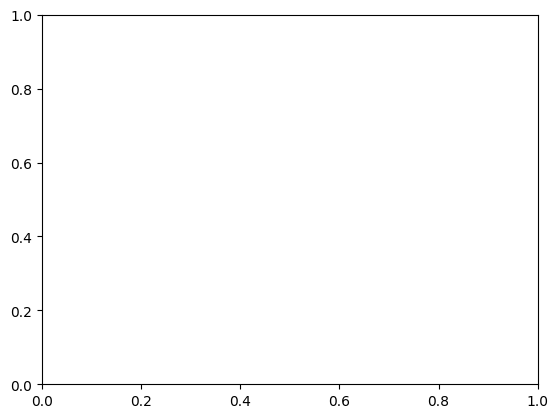

In [49]:
t = np.linspace(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1], 1000)
i = 1
for params in interest_vals[:50]:
    plt.plot(t, evalPdf(splinefit_3d, params[1], params[2], t))
    plt.title(f"dist={params[1]:.2f}, phiE={params[2]:.2f}, tres={params[3]:.2f}, cdf={params[0]:.2e}")
    plt.vlines(params[3], ymin=0, ymax=max(evalPdf(splinefit_3d, params[1], params[2], t)), colors='r', linestyles='dashed', label = 'Sampled Tres')
    plt.yscale('log')
    plt.savefig(f'/mnt/home/dillonb5/cascades/plots/cdf_spike_{i}.png')
    i += 1
    plt.cla()
    